In [10]:
from google.colab import drive
drive.mount('/content/drive')

!pip install lightkurve astroquery --quiet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from scipy.ndimage import uniform_filter1d

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# ============================================================
# CELL 3 — LOAD DATASETS
# ============================================================
X_raw    = np.load("/content/drive/MyDrive/X_kepler.npy", allow_pickle=True)
y_raw    = np.load("/content/drive/MyDrive/y_kepler.npy", allow_pickle=True)
g_raw    = np.load("/content/drive/MyDrive/groups_kepler.npy", allow_pickle=True)

X_folded = np.load("/content/drive/MyDrive/X_folded.npy", allow_pickle=True)
y_folded = np.load("/content/drive/MyDrive/y_folded.npy", allow_pickle=True)
g_folded = np.load("/content/drive/MyDrive/groups_folded.npy", allow_pickle=True)

X_raw    = X_raw.reshape(-1, 400, 1)
X_folded = X_folded.reshape(-1, 200, 1)

def recenter_dip(x):
    smoothed = uniform_filter1d(x, size=10)
    dip_pos  = np.argmin(smoothed)
    center   = len(x) // 2
    shift    = center - dip_pos
    return np.roll(x, shift)

X_folded_recentered = np.array([recenter_dip(x.flatten()) for x in X_folded])
X_folded_recentered = X_folded_recentered.reshape(-1, 200, 1)

print("Raw dataset:              ", X_raw.shape, "labels:", np.bincount(y_raw))
print("Folded dataset:           ", X_folded.shape, "labels:", np.bincount(y_folded))
print("Folded recentered dataset:", X_folded_recentered.shape)

In [14]:
# ============================================================
# CELL 3 — LOAD DATASETS
# ============================================================
X_raw    = np.load("/content/drive/MyDrive/X_kepler.npy", allow_pickle=True)
y_raw    = np.load("/content/drive/MyDrive/y_kepler.npy", allow_pickle=True)
g_raw    = np.load("/content/drive/MyDrive/groups_kepler.npy", allow_pickle=True)

X_folded = np.load("/content/drive/MyDrive/X_folded.npy", allow_pickle=True)
y_folded = np.load("/content/drive/MyDrive/y_folded.npy", allow_pickle=True)
g_folded = np.load("/content/drive/MyDrive/groups_folded.npy", allow_pickle=True)

X_raw    = X_raw.reshape(-1, 400, 1)
X_folded = X_folded.reshape(-1, 200, 1)

def recenter_dip(x):
    smoothed = uniform_filter1d(x, size=10)
    dip_pos  = np.argmin(smoothed)
    center   = len(x) // 2
    shift    = center - dip_pos
    return np.roll(x, shift)

X_folded_recentered = np.array([recenter_dip(x.flatten()) for x in X_folded])
X_folded_recentered = X_folded_recentered.reshape(-1, 200, 1)

print("Raw dataset:              ", X_raw.shape, "labels:", np.bincount(y_raw))
print("Folded dataset:           ", X_folded.shape, "labels:", np.bincount(y_folded))
print("Folded recentered dataset:", X_folded_recentered.shape)

Raw dataset:               (1000, 400, 1) labels: [500 500]
Folded dataset:            (995, 200, 1) labels: [496 499]
Folded recentered dataset: (995, 200, 1)


In [3]:
# ============================================================
# CELL 4 — MODEL BUILDERS
# ============================================================
def build_model_raw_heavy():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, 7, padding="same", input_shape=(400, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 5, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

def build_model_raw_light():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, 7, activation="relu", padding="same", input_shape=(400, 1)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 5, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

def build_model_folded_heavy():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, 7, padding="same", input_shape=(200, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 5, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

def build_model_folded_light():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, 7, activation="relu", padding="same", input_shape=(200, 1)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 5, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

In [23]:
# ============================================================
# CELL 5 — TRAINING FUNCTION
# ============================================================
def train_and_evaluate(X, y, groups, model_builder, label, seeds=range(200,205)):

    all_aucs     = []
    all_accs     = []
    best_auc     = 0
    best_history = None
    best_preds   = None
    best_y_test  = None

    for seed in seeds:
        print(f"\n  [{label}] seed {seed}")

        gss = GroupShuffleSplit(test_size=0.2, random_state=seed)
        train_idx, test_idx = next(gss.split(X, y, groups))

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        class_weights = {i: cw[i] for i in range(len(cw))}

        model = model_builder()

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", patience=25, mode="max",
            restore_best_weights=True, verbose=0
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=150,
            batch_size=16,
            class_weight=class_weights,
            callbacks=[early_stop],
            verbose=0
        )

        loss, auc, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"    AUC={auc:.4f}  Acc={acc:.4f}")

        all_aucs.append(auc)
        all_accs.append(acc)

        if auc > best_auc:
            best_auc     = auc
            best_history = history
            best_preds   = model.predict(X_test, verbose=0).flatten()
            best_y_test  = y_test

    print(f"\n  {label} — Mean AUC: {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}")
    print(f"  {label} — Mean Acc: {np.mean(all_accs):.4f} ± {np.std(all_accs):.4f}")

    return {
        "label":    label,
        "aucs":     all_aucs,
        "accs":     all_accs,
        "mean_auc": np.mean(all_aucs),
        "std_auc":  np.std(all_aucs),
        "mean_acc": np.mean(all_accs),
        "history":  best_history,
        "preds":    best_preds,
        "y_test":   best_y_test
    }

In [24]:
# ============================================================
# CELL 6 — RUN ALL 5
# ============================================================
print("=" * 50)
print("1/5 RAW SNIPPET (HEAVY ARCH)")
print("=" * 50)
results_raw_heavy = train_and_evaluate(X_raw, y_raw, g_raw, build_model_raw_heavy, "Raw Snippet (Heavy Arch)")

print("\n" + "=" * 50)
print("2/5 RAW SNIPPET (LIGHT ARCH)")
print("=" * 50)
results_raw_light = train_and_evaluate(X_raw, y_raw, g_raw, build_model_raw_light, "Raw Snippet (Light Arch)")

print("\n" + "=" * 50)
print("3/5 PHASE FOLDED (HEAVY ARCH)")
print("=" * 50)
results_folded_heavy = train_and_evaluate(X_folded, y_folded, g_folded, build_model_folded_heavy, "Phase Folded (Heavy Arch)")

print("\n" + "=" * 50)
print("4/5 PHASE FOLDED (LIGHT ARCH)")
print("=" * 50)
results_folded_light = train_and_evaluate(X_folded, y_folded, g_folded, build_model_folded_light, "Phase Folded (Light Arch)")

print("\n" + "=" * 50)
print("5/5 PHASE FOLDED RECENTERED (LIGHT ARCH)")
print("=" * 50)
results_folded_recentered = train_and_evaluate(X_folded_recentered, y_folded, g_folded, build_model_folded_light, "Phase Folded Recentered (Light Arch)")

1/5 RAW SNIPPET (HEAVY ARCH)

  [Raw Snippet (Heavy Arch)] seed 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    AUC=0.8797  Acc=0.8000

  [Raw Snippet (Heavy Arch)] seed 201


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    AUC=0.8496  Acc=0.7525

  [Raw Snippet (Heavy Arch)] seed 202


...

    AUC=0.8212  Acc=0.7400

  [Phase Folded Recentered (Light Arch)] seed 203


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    AUC=0.7880  Acc=0.7574

  [Phase Folded Recentered (Light Arch)] seed 204


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    AUC=0.8440  Acc=0.7766

  Phase Folded Recentered (Light Arch) — Mean AUC: 0.8292 ± 0.0315
  Phase Folded Recentered (Light Arch) — Mean Acc: 0.7643 ± 0.0149


In [25]:
all_results = [
    results_raw_heavy,
    results_raw_light,
    results_folded_heavy,
    results_folded_light,
    results_folded_recentered
]

print("\n")
print("=" * 70)
print("FINAL 5-WAY COMPARISON")
print("=" * 70)
print(f"{'Method':<40} {'Mean AUC':>10} {'Std AUC':>10} {'Mean Acc':>10}")
print("-" * 70)
for r in all_results:
    print(f"{r['label']:<40} {r['mean_auc']:>10.4f} {r['std_auc']:>10.4f} {r['mean_acc']:>10.4f}")



FINAL 5-WAY COMPARISON
Method                                     Mean AUC    Std AUC   Mean Acc
----------------------------------------------------------------------
Raw Snippet (Heavy Arch)                     0.8412     0.0287     0.7162
Raw Snippet (Light Arch)                     0.8230     0.0293     0.7505
Phase Folded (Heavy Arch)                    0.7699     0.0185     0.4646
Phase Folded (Light Arch)                    0.8600     0.0282     0.7942
Phase Folded Recentered (Light Arch)         0.8292     0.0315     0.7643



Classification Report — Raw Snippet (Heavy Arch)
              precision    recall  f1-score   support

  Non-planet       0.96      0.66      0.78       108
      Planet       0.71      0.97      0.82        92

    accuracy                           0.80       200
   macro avg       0.83      0.81      0.80       200
weighted avg       0.84      0.80      0.80       200



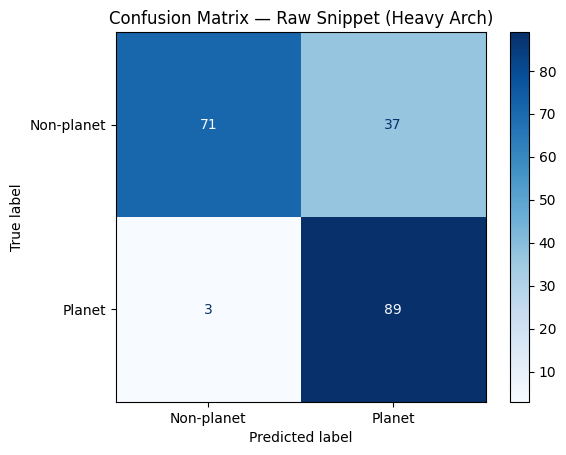


Classification Report — Raw Snippet (Light Arch)
              precision    recall  f1-score   support

  Non-planet       0.85      0.69      0.76        89
      Planet       0.78      0.90      0.84       110

    accuracy                           0.80       199
   macro avg       0.81      0.79      0.80       199
weighted avg       0.81      0.80      0.80       199



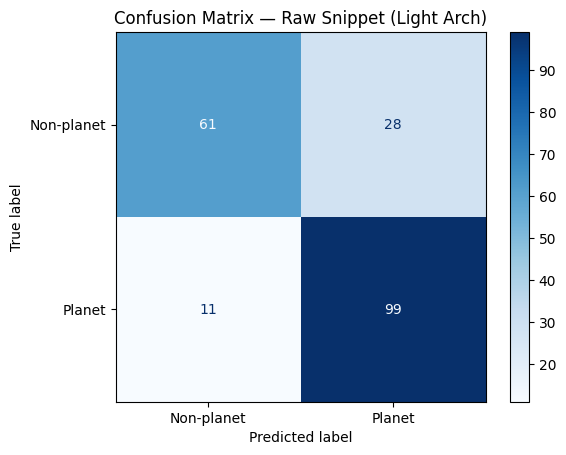


Classification Report — Phase Folded (Heavy Arch)
              precision    recall  f1-score   support

  Non-planet       0.48      0.99      0.65        98
      Planet       0.00      0.00      0.00       104

    accuracy                           0.48       202
   macro avg       0.24      0.49      0.32       202
weighted avg       0.23      0.48      0.31       202



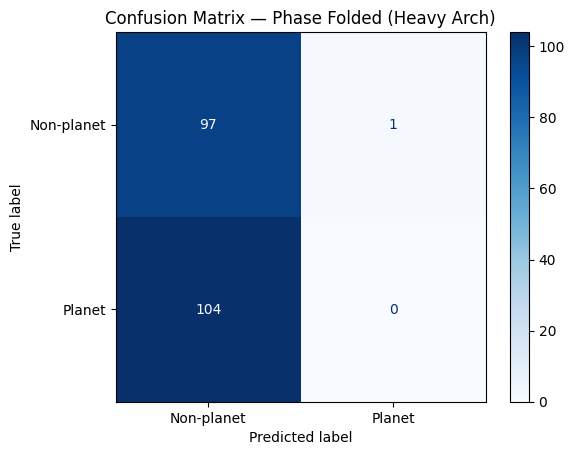


Classification Report — Phase Folded (Light Arch)
              precision    recall  f1-score   support

  Non-planet       0.87      0.77      0.82        98
      Planet       0.80      0.89      0.85       104

    accuracy                           0.83       202
   macro avg       0.84      0.83      0.83       202
weighted avg       0.84      0.83      0.83       202



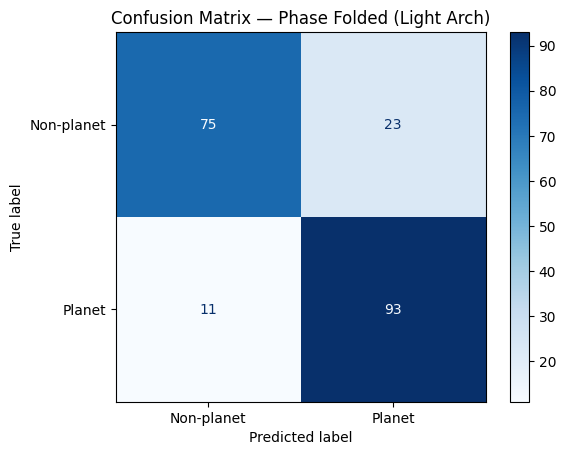


Classification Report — Phase Folded Recentered (Light Arch)
              precision    recall  f1-score   support

  Non-planet       0.85      0.67      0.75        98
      Planet       0.74      0.88      0.81       104

    accuracy                           0.78       202
   macro avg       0.79      0.78      0.78       202
weighted avg       0.79      0.78      0.78       202



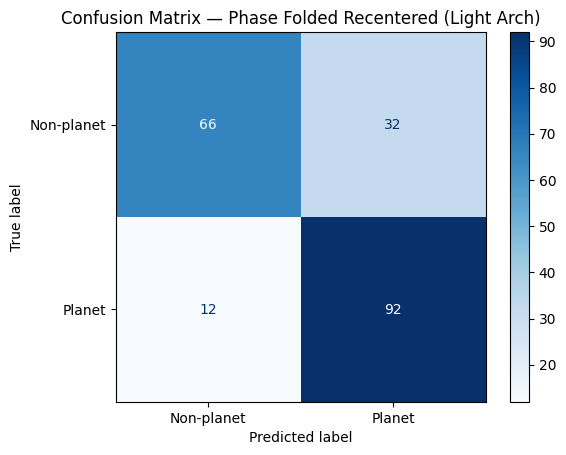

In [26]:
# ============================================================
# CELL 8 — CLASSIFICATION REPORTS
# ============================================================
for r in all_results:
    print(f"\nClassification Report — {r['label']}")
    y_pred = (r["preds"] > 0.5).astype(int)
    print(classification_report(r["y_test"], y_pred, target_names=["Non-planet", "Planet"]))

    cm = confusion_matrix(r["y_test"], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-planet", "Planet"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {r['label']}")
    plt.show()

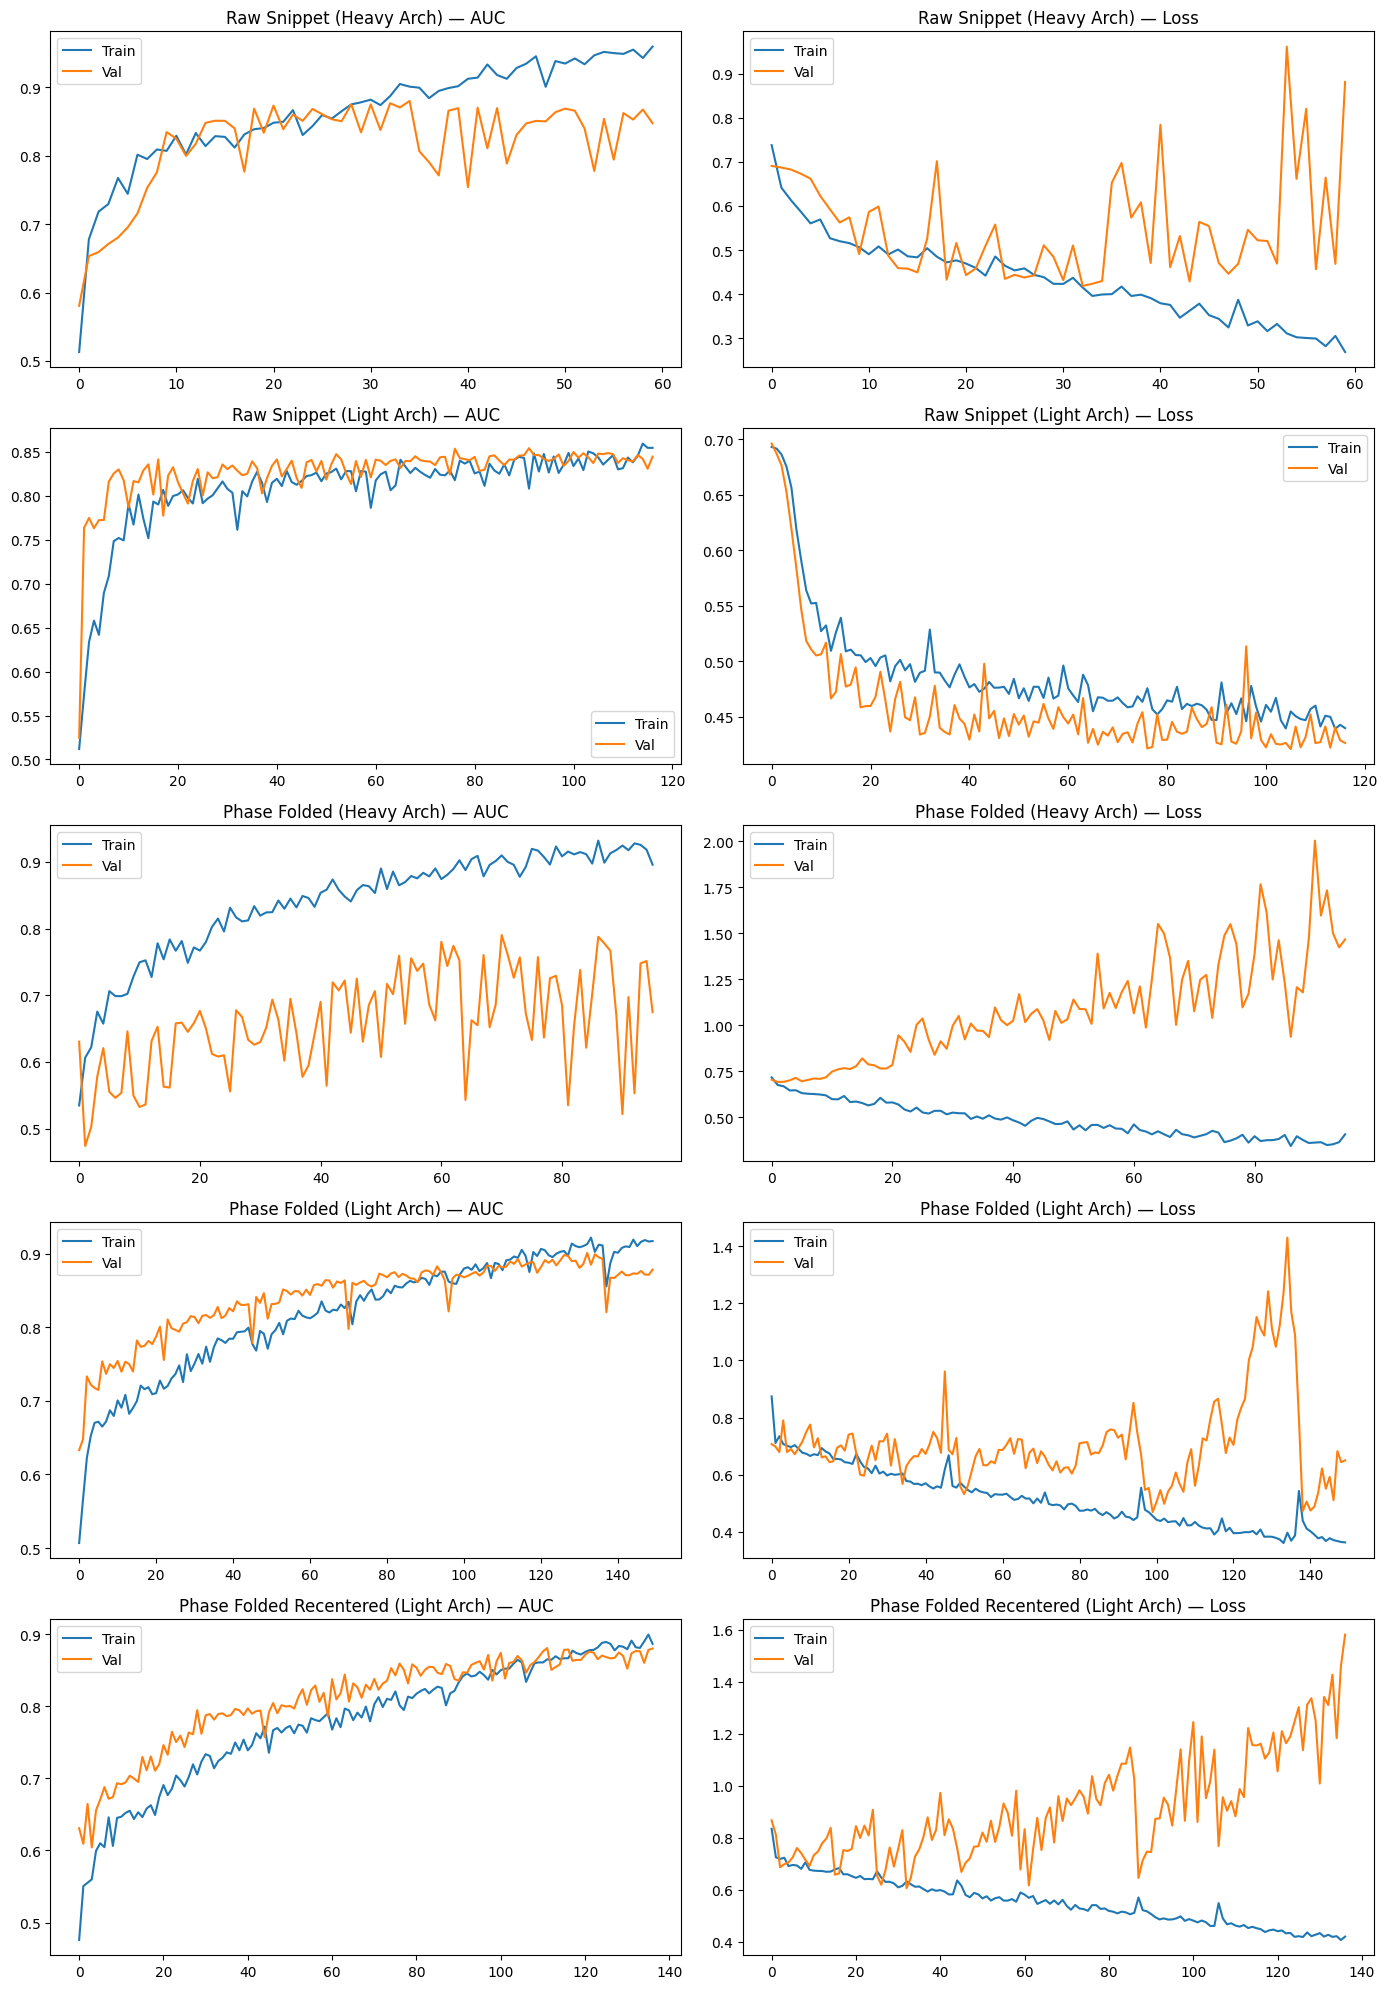

In [27]:
# ============================================================
# CELL 9 — TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, r in enumerate(all_results):
    axes[i][0].plot(r["history"].history["auc"],     label="Train")
    axes[i][0].plot(r["history"].history["val_auc"], label="Val")
    axes[i][0].set_title(f"{r['label']} — AUC")
    axes[i][0].legend()

    axes[i][1].plot(r["history"].history["loss"],     label="Train")
    axes[i][1].plot(r["history"].history["val_loss"], label="Val")
    axes[i][1].set_title(f"{r['label']} — Loss")
    axes[i][1].legend()

plt.tight_layout()
plt.show()



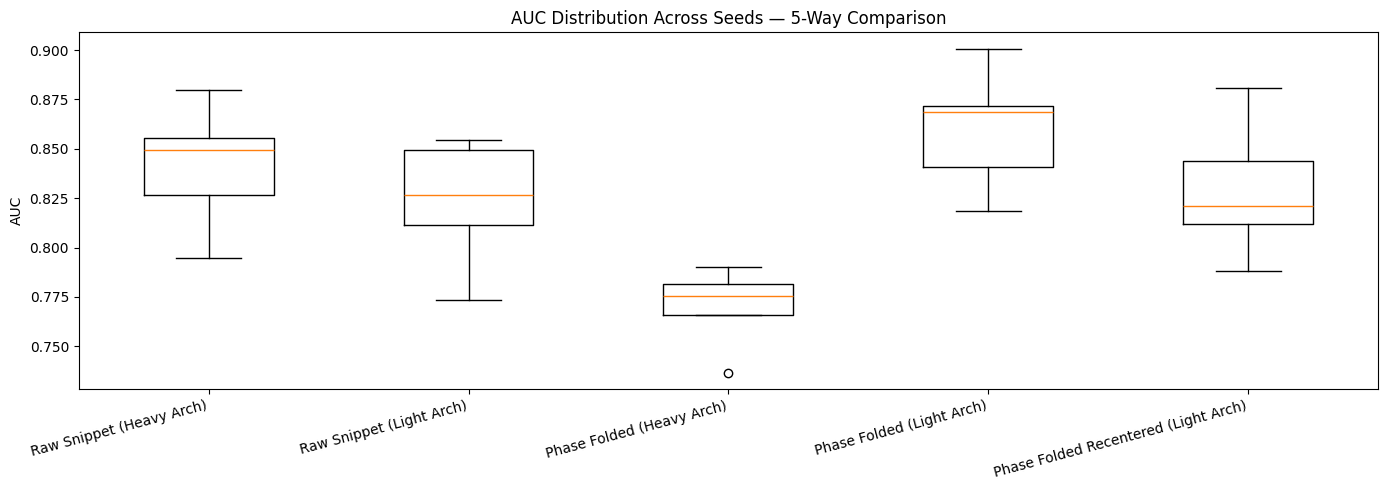

In [28]:
# ============================================================
# CELL 10 — BOXPLOT
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(
    [r["aucs"] for r in all_results],
    tick_labels=[r["label"] for r in all_results]
)
ax.set_ylabel("AUC")
ax.set_title("AUC Distribution Across Seeds — 5-Way Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

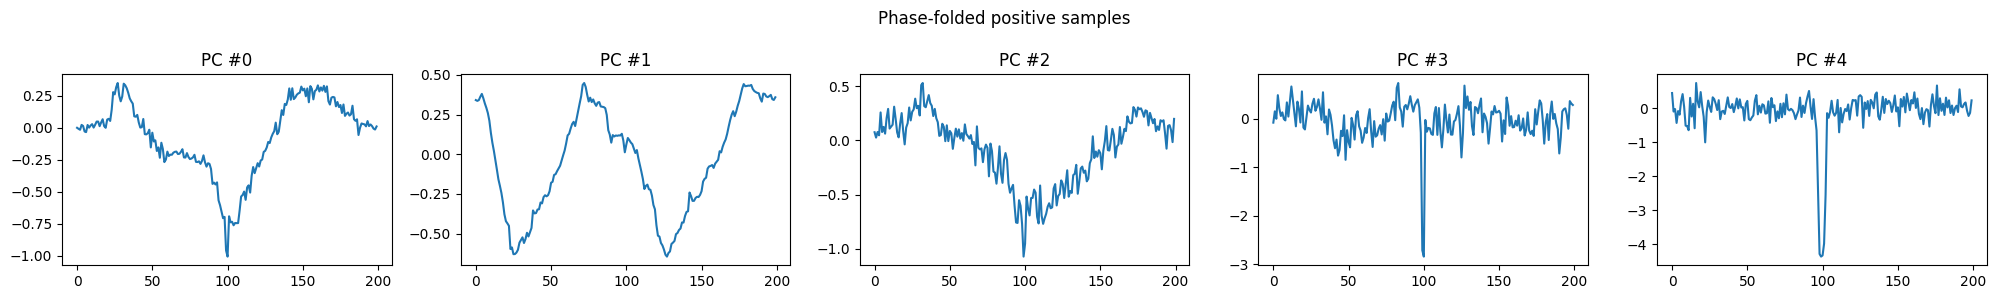

In [15]:
import numpy as np
import matplotlib.pyplot as plt

X_folded = np.load("/content/drive/MyDrive/X_folded.npy", allow_pickle=True)
y = np.load("/content/drive/MyDrive/y_folded.npy", allow_pickle=True)

X_folded = X_folded.reshape(-1, 200, 1)

pos_idx = np.where(y == 1)[0][:5]
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, idx in enumerate(pos_idx):
    axes[i].plot(X_folded[idx].flatten())
    axes[i].set_title(f"PC #{idx}")
plt.suptitle("Phase-folded positive samples")
plt.tight_layout()
plt.show()